# Klasifikasi DemogPairs Menggunakan Fitur ViT (Wajah, Emosi, dan Umur) & Gaussian Naive Baye

In [2]:
import numpy as np
import utilsv2 as u
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, ParameterGrid
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from tqdm import tqdm

joblib.parallel_backend('threading')

## Load Dataset

In [3]:
data = u.load_demogpairs()
pd.DataFrame(data)

,db_code,image_path,full_path,label,label_idx
0,CWF,able_wanamakok/002.jpg,dataset/demogpairs/images/able_wanamakok/002.jpg,Asian_Females,5
1,CWF,able_wanamakok/004.jpg,dataset/demogpairs/images/able_wanamakok/004.jpg,Asian_Females,5
2,CWF,able_wanamakok/007.jpg,dataset/demogpairs/images/able_wanamakok/007.jpg,Asian_Females,5
3,CWF,able_wanamakok/008.jpg,dataset/demogpairs/images/able_wanamakok/008.jpg,Asian_Females,5
4,CWF,able_wanamakok/012.jpg,dataset/demogpairs/images/able_wanamakok/012.jpg,Asian_Females,5
...,...,...,...,...,...
10795,CWF,zachary_quinto/177.jpg,dataset/demogpairs/images/zachary_quinto/177.jpg,White_Males,3
10796,CWF,zachary_quinto/214.jpg,dataset/demogpairs/images/zachary_quinto/214.jpg,White_Males,3
10797,CWF,zachary_quinto/217.jpg,dataset/demogpairs/images/zachary_quinto/217.jpg,White_Males,3
10798,CWF,zachary_quinto/218.jpg,dataset/demogpairs/images/zachary_quinto/218.jpg,White_Males,3


## Load Fitur

In [4]:
vggface_features = joblib.load('features/demogpairs_vit-face.pkl')
emotion_features = joblib.load('features/demogpairs_vit-emotion.pkl')
age_features = joblib.load('features/demogpairs_vit-age.pkl')
features = {}
for d in tqdm(data):
    key = d['image_path']
    features[key] = np.array(list(vggface_features[key]) + list(emotion_features[key]) + list(age_features[key]))
print('Jumlah fitur per gambar:', np.array(features[list(features.keys())[0]]).shape[0])

100%|██████████████████████████████████████████████████████████████████████████| 10800/10800 [00:01<00:00, 5683.61it/s]

Jumlah fitur per gambar: 2304


## Split Data

In [5]:
X = np.array([features[d['image_path']] for d in data])
y = np.array([d['label_idx'] for d in data])
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print((len(X_train), len(X_test)))

(8640, 2160)


## Kombinasi Parameter

In [6]:
var_smoothing_values = np.logspace(-9, 2, 40)  # dari 1e-9 sampai 1e2, 40 nilai

grid_params = [
    {
        'scaler': [None, MinMaxScaler()],  # EN: scaling option / ID: opsi scaling
        'pca': [None, PCA(n_components=0.5), PCA(n_components=0.75)],  # EN: with and without PCA / ID: dengan dan tanpa PCA
        
        'classifier': [GaussianNB()],
        'classifier__var_smoothing': var_smoothing_values
    }
]

pipeline = Pipeline(steps=[
    ('scaler', None),  # EN: optional scaler / ID: scaler opsional
    ('pca', None),     # EN: optional PCA / ID: PCA opsional
    ('classifier', None)  # EN: classifier / ID: classifier
])

skv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy', 
    'f1': 'f1_macro', 
    'precision': 'precision_macro', 
    'recall': 'recall_macro',
    # 'roc_auc_ovr': 'roc_auc_ovr'
}

grid_models = {}
for params in grid_params:
    key = str(params['classifier'][0]).split('(')[0]
    grid_models[key] = GridSearchCV(
        estimator=pipeline,
        param_grid=params,
        cv=skv, refit='accuracy',
        scoring=scoring, n_jobs=int(joblib.cpu_count() * 0.8),
        verbose=1, error_score='raise',
        return_train_score=True
    )
    print(f'{key}: {len(ParameterGrid(params))} kombinasi')

GaussianNB: 240 kombinasi


## Klasifikasi

Mengevaluasi model: GaussianNB
Fitting 5 folds for each of 240 candidates, totalling 1200 fits


{'classifier': 'GaussianNB', 'classifier__var_smoothing': np.float64(0.0058780160722749115), 'pca': 'PCA', 'scaler': None}


Accuracy  : 0.850462962962963
Precision : 0.8511707945960275
Recall    : 0.850462962962963
F1 Score  : 0.8504916506760488
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       360
           1       0.86      0.88      0.87       360
           2       0.83      0.81      0.82       360
           3       0.89      0.89      0.89       360
           4       0.86      0.80      0.83       360
           5       0.79      0.84      0.81       360

    accuracy                           0.85      2160
   macro avg       0.85      0.85      0.85      2160
weighted avg       0.85      0.85      0.85      2160



Class,Accuracy,Precision,Recall,F1-Score
Black_Males,0.9597222222222223,0.8781163434903048,0.8805555555555555,0.8793342579750347
White_Females,0.9574074074074074,0.8641304347826086,0.8833333333333333,0.8736263736263736
Asian_Males,0.9402777777777778,0.8271954674220963,0.8111111111111111,0.8190743338008415
White_Males,0.9634259259259259,0.8935574229691877,0.8861111111111111,0.8898186889818689
Black_Females,0.9449074074074074,0.857566765578635,0.8027777777777778,0.8292682926829268
Asian_Females,0.9351851851851852,0.7864583333333334,0.8388888888888889,0.8118279569892473


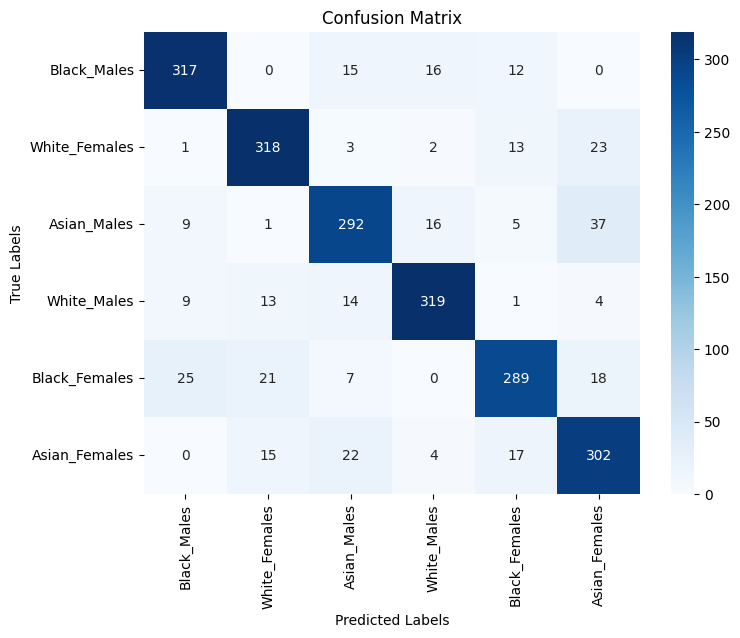

model_name,model_file_path,best_parameters,test_accuracy,test_f1,test_precision,test_recall,parameter_combinations
GaussianNB,models/clf_demogpairs_gnb_vit-face-emotion-age_GaussianNB.pkl,"{'classifier': 'GaussianNB', 'classifier__var_smoothing': np.float64(0.0058780160722749115), 'pca': 'PCA', 'scaler': None}",0.850462962962963,0.8504916506760488,0.8511707945960275,0.850462962962963,240


In [7]:
evaluation_results, fold_results = u.evaluate_models(
    grid_models,
    X_train, y_train,
    X_test, y_test,
    model_prefix='models/clf_demogpairs_gnb_vit-face-emotion-age_',
    results_path='results/demogpairs_gnb_vit-face-emotion-age_'
)

sorted_results = pd.DataFrame(evaluation_results).sort_values(by='test_accuracy', ascending=False).to_dict('records')
u.html_br()
_dtable = u.display_table(sorted_results)

In [8]:
model, training_time = u.load_object('models/clf_demogpairs_gnb_vit-face-emotion-age_GaussianNB.pkl')
u.h(5, 'Waktu Pelatihan (Jobs)')
u.seconds_to_time(round(training_time))

{'input_seconds': 3096.0,
 'days': 0,
 'hours': 0,
 'minutes': 51,
 'seconds': 36.0,
 'text': '0 hari 0 jam 51 menit 36.0 detik'}

In [9]:
u.h(5, 'Waktu Pelatihan')
times = [fr['Train Time Mean'] * 5 for fr in fold_results]
u.seconds_to_time(round(np.sum(times) + model.refit_time_))

{'input_seconds': 24987.0,
 'days': 0,
 'hours': 6,
 'minutes': 56,
 'seconds': 27.0,
 'text': '0 hari 6 jam 56 menit 27.0 detik'}

In [10]:
def remove_keys(data, keys_to_remove, inplace=False):
    # EN: if not inplace, create a copy / ID: jika tidak inplace, buat salinan
    if not inplace:
        data = data.copy()
    
    # EN: loop through keys and remove safely / ID: loop key dan hapus dengan aman
    for key in keys_to_remove:
        data.pop(key, None)  # EN: avoid error if key not found / ID: aman jika key tidak ada
    
    return data

def dict_to_sentence(d):
    # EN: convert key-value pairs into readable parts / ID: ubah key-value jadi bagian kalimat
    parts = [f"{k}={v}" for k, v in d.items()]
    
    # EN: join all parts into one sentence / ID: gabungkan jadi satu kalimat
    sentence = ", ".join(parts)
    
    return sentence

fold_displays = []
for r in [remove_keys(r, ['No', 'F1 Score Mean', 'Precision Mean', 'Recall Mean', 'Train Time Mean']) for r in fold_results]:
    r['Params'] = dict_to_sentence(remove_keys(r['Params'], ['classifier'])).replace('classifier__', '')
    r['Mean'] = r['Accuracy Mean']
    del r['Accuracy Mean']
    fold_displays.append(r)
fold_displays = [{'No': idx + 1, **r} for idx, r in enumerate(sorted(fold_displays, key=lambda x: x['Mean'], reverse=True))]
_dtable = u.display_table(fold_displays, n_items=[3, 3, 3, 3], column_widths=['5%', '65%', '5%', '5%', '5%', '5%', '5%', '5%'])

No,Params,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean
1,"var_smoothing=0.0058780160722749115, pca=PCA, scaler=None",0.8571,0.8484,0.8507,0.8582,0.8623,0.8553
2,"var_smoothing=0.00307029062975785, pca=PCA, scaler=None",0.8519,0.8461,0.8438,0.8559,0.8657,0.8527
3,"var_smoothing=0.011253355826007646, pca=PCA, scaler=None",0.853,0.842,0.8553,0.8559,0.8571,0.8527
...,...,...,...,...,...,...,...
80,"var_smoothing=3.665241237079626e-09, pca=PCA, scaler=MinMaxScaler",0.8426,0.8333,0.8281,0.8316,0.8438,0.8359
81,"var_smoothing=8.886238162743407e-06, pca=PCA, scaler=MinMaxScaler",0.8426,0.8333,0.8281,0.8316,0.8438,0.8359
82,"var_smoothing=4.641588833612773e-06, pca=PCA, scaler=MinMaxScaler",0.8426,0.8333,0.8281,0.8316,0.8438,0.8359
...,...,...,...,...,...,...,...
159,"var_smoothing=1.9144819761699614e-09, pca=None, scaler=None",0.8287,0.8223,0.8166,0.8235,0.8177,0.8218
160,"var_smoothing=1.9144819761699614e-09, pca=None, scaler=MinMaxScaler",0.8287,0.8223,0.8166,0.8235,0.8177,0.8218
